# Clustering

**Part 1** - Case Study

**Part 2** - K-Means, Step by Step

**Part 3** - DBSCAN on Two Moons

**Part 4** - Anomaly Detection with DBSCAN

---
# Part 1: Case Study

# Customer Segmentation Case Study — Clustering

A quick, self-contained walkthrough: generate synthetic customer
data, look at it with no labels, discover
customer segments using clustering.


### Generate synthetic customer data

Create 4 underlying customer groups (age, income, spending score)
so we have a dataset with known structure to cluster.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

segment1 = np.random.multivariate_normal(
    mean=[22, 25, 25],
    cov=[[8,0,0],
         [0,20,0],
         [0,0,25]],
    size=80
)

segment2 = np.random.multivariate_normal(
    mean=[30, 80, 85],
    cov=[[10,0,0],
         [0,30,0],
         [0,0,20]],
    size=80
)

segment3 = np.random.multivariate_normal(
    mean=[48, 70, 55],
    cov=[[15,0,0],
         [0,25,0],
         [0,0,25]],
    size=80
)

segment4 = np.random.multivariate_normal(
    mean=[62, 45, 30],
    cov=[[12,0,0],
         [0,20,0],
         [0,0,20]],
    size=80
)

customers = np.vstack((segment1,
                       segment2,
                       segment3,
                       segment4))

df = pd.DataFrame(customers,
                  columns=["Age",
                           "Income",
                           "SpendingScore"])

print(df.head())


         Age     Income  SpendingScore
0  23.831940  24.381663      27.483571
1  21.337761  23.952834      32.615149
2  20.672126  28.432072      32.896064
3  20.682717  22.927533      27.712800
4  17.121196  16.443551      26.209811


### Visualize the raw data

Plot income vs. spending score with no group labels — just to see
what we're working with before any clustering happens.


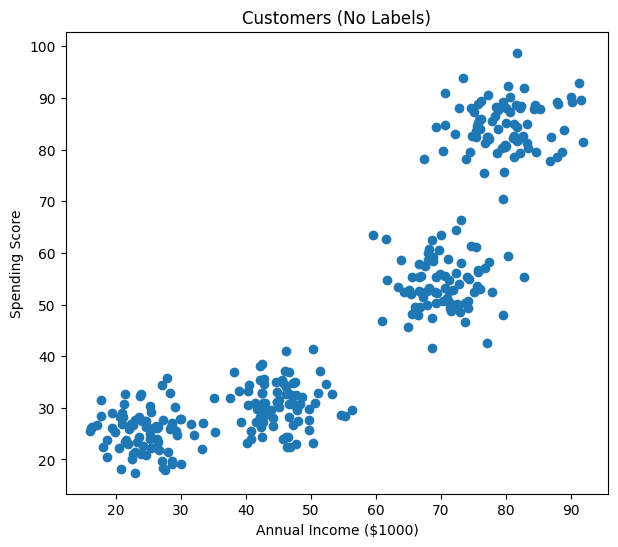

In [2]:
plt.figure(figsize=(7,6))

plt.scatter(df["Income"],
            df["SpendingScore"])

plt.xlabel("Annual Income ($1000)")
plt.ylabel("Spending Score")
plt.title("Customers (No Labels)")

plt.show()


### Cluster the customers with K-Means

Run K-Means with 4 clusters, then plot each discovered segment in
its own color.


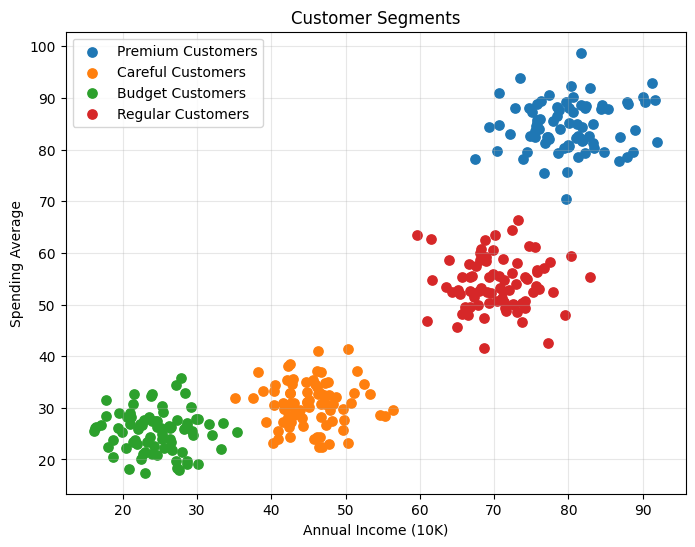

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

X = df[["Income", "SpendingScore"]].values

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

cluster_names = ["Premium Customers", "Careful Customers", "Budget Customers", "Regular Customers"]

plt.figure(figsize=(8,6))

for i in range(4):
    plt.scatter(
        X[labels == i, 0],
        X[labels == i, 1],
        s=45,
        label=cluster_names[i]
    )

plt.xlabel("Annual Income (10K)")
plt.ylabel("Spending Average")
plt.title("Customer Segments")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


---
# Part 2: K-Means, Step by Step

# How K-Means Actually Works, Step by Step

In the other notebook we just called `KMeans().fit()` and got an
answer. That's great in practice, but it hides *how* the algorithm
actually finds the clusters.

This notebook opens up that black box. We'll implement K-Means
ourselves, one step at a time, and **plot the clusters after every
single step** so you can watch them form in front of you.

K-Means boils down to repeating just two moves:

1. **Assign** — give every point to its nearest cluster center
2. **Update** — move each center to the average position of the
   points assigned to it

...and repeat until nothing changes. That's the whole algorithm.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

np.random.seed(42)
plt.rcParams["figure.figsize"] = (6, 5)

# Step 0: Some simple data

We'll generate a small synthetic dataset with 3 obvious groups, so
it's easy to watch K-Means find them.

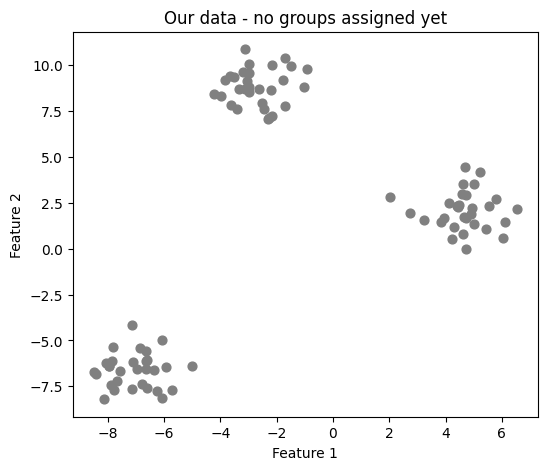

In [5]:
X, _ = make_blobs(n_samples=90, centers=3, cluster_std=1.0, random_state=42)

plt.scatter(X[:, 0], X[:, 1], s=40, color="gray")
plt.title("Our data - no groups assigned yet")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Step 1: Pick starting cluster centers (randomly)

K-Means has to start somewhere. The simplest approach: pick a few
random points from the data and treat them as the first guess at
cluster centers.

Here we're asking for **k = 3** clusters, so we pick 3 random
starting points.

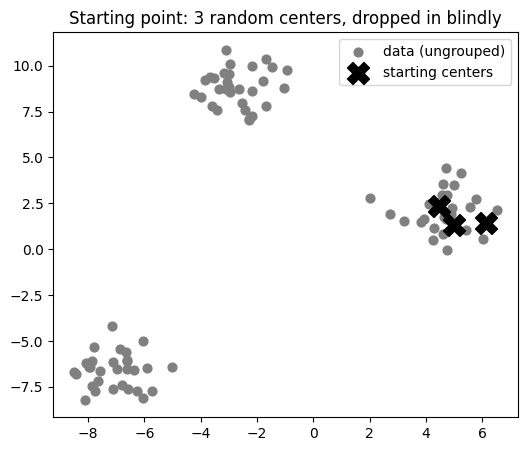

In [6]:
k = 3

rng = np.random.default_rng(7)
initial_idx = rng.choice(len(X), size=k, replace=False)
centers = X[initial_idx].copy()

plt.scatter(X[:, 0], X[:, 1], s=40, color="gray", label="data (ungrouped)")
plt.scatter(centers[:, 0], centers[:, 1], s=250, marker="X", c="black", label="starting centers")
plt.title("Starting point: 3 random centers, dropped in blindly")
plt.legend()
plt.show()


# Step 2: The two moves, repeated

Now we'll write two small functions:

- `assign_clusters` — for every point, find the *nearest* center
  and assign the point to that cluster
- `update_centers` — move each center to the average position of
  the points now assigned to it

Then we'll run them over and over, plotting after each round.

In [7]:
def assign_clusters(X, centers):
    # distance from every point to every center
    distances = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)
    # each point goes to whichever center is closest
    return np.argmin(distances, axis=1)

def update_centers(X, labels, k):
    return np.array([X[labels == i].mean(axis=0) for i in range(k)])

def plot_state(X, labels, centers, title):
    colors = ["steelblue", "darkorange", "seagreen", "purple", "gold"]
    plt.figure(figsize=(6, 5))
    if labels is None:
        plt.scatter(X[:, 0], X[:, 1], s=40, color="gray")
    else:
        for i in range(len(centers)):
            pts = X[labels == i]
            plt.scatter(pts[:, 0], pts[:, 1], s=40, color=colors[i], label=f"Cluster {i}")
    plt.scatter(centers[:, 0], centers[:, 1], s=250, marker="X", c="black", label="centers")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()

## Iteration 1: Assign, then update

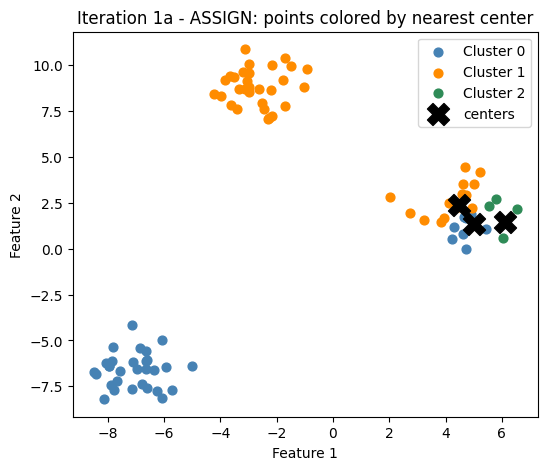

In [8]:
labels = assign_clusters(X, centers)
plot_state(X, labels, centers, "Iteration 1a - ASSIGN: points colored by nearest center")

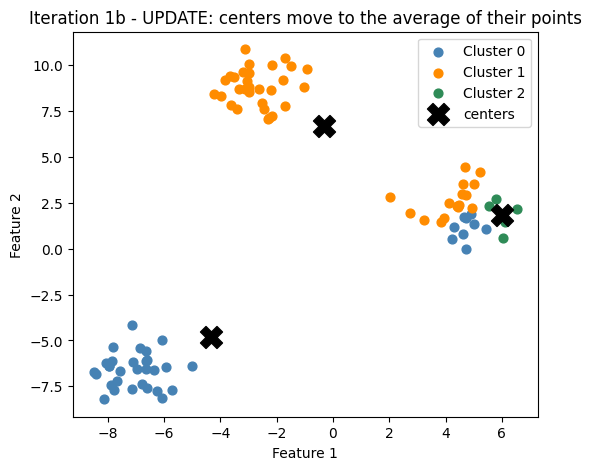

In [9]:
centers = update_centers(X, labels, k)
plot_state(X, labels, centers, "Iteration 1b - UPDATE: centers move to the average of their points")

## Iteration 2: Assign, then update again

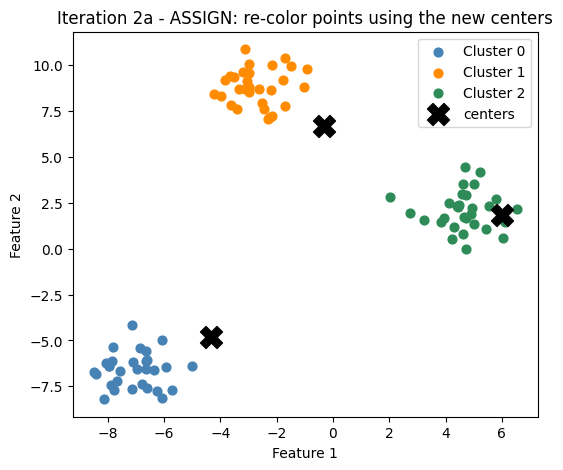

In [10]:
labels = assign_clusters(X, centers)
plot_state(X, labels, centers, "Iteration 2a - ASSIGN: re-color points using the new centers")

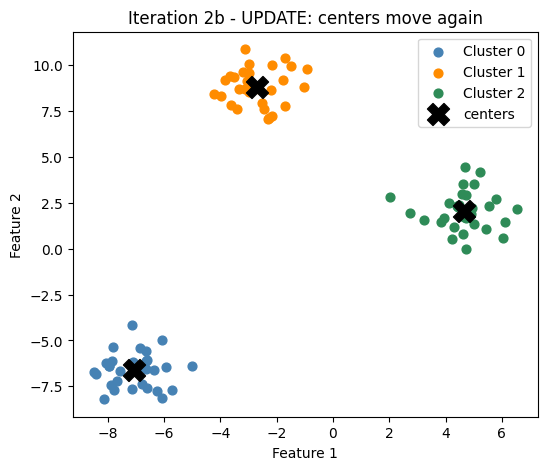

In [11]:
centers = update_centers(X, labels, k)
plot_state(X, labels, centers, "Iteration 2b - UPDATE: centers move again")

## Iteration 3: One more round

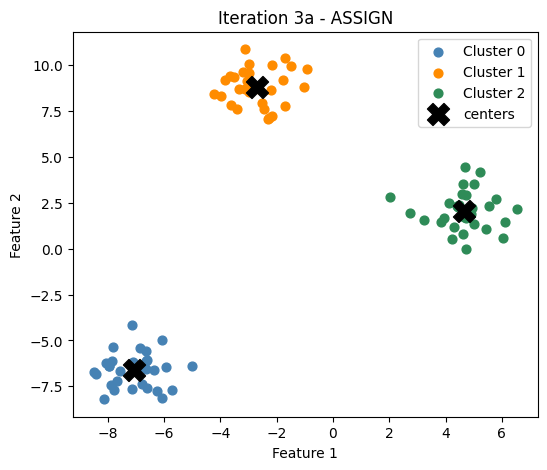

In [12]:
labels = assign_clusters(X, centers)
plot_state(X, labels, centers, "Iteration 3a - ASSIGN")

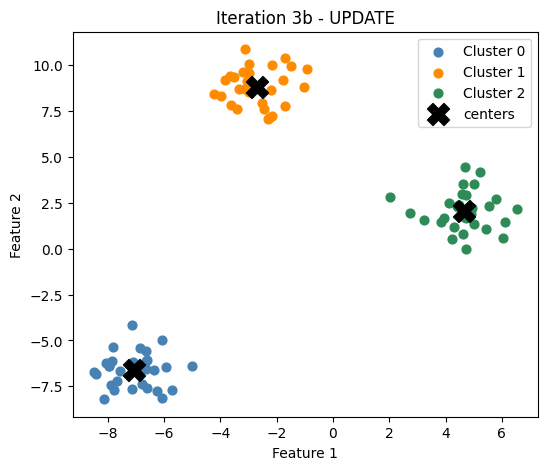

In [13]:
centers = update_centers(X, labels, k)
plot_state(X, labels, centers, "Iteration 3b - UPDATE")

# KMeans: Summary

In [14]:
def run_kmeans_with_history(X, k, seed=7, max_iter=10, tol=1e-4):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=k, replace=False)
    centers = X[idx].copy()

    history = []  # (labels, centers) after each full iteration
    for iteration in range(max_iter):
        labels = assign_clusters(X, centers)
        new_centers = update_centers(X, labels, k)
        history.append((labels, new_centers.copy()))

        shift = np.linalg.norm(new_centers - centers)
        centers = new_centers
        if shift < tol:
            break

    return history

history = run_kmeans_with_history(X, k=3, seed=7)
print(f"K-Means converged after {len(history)} iterations")

K-Means converged after 3 iterations


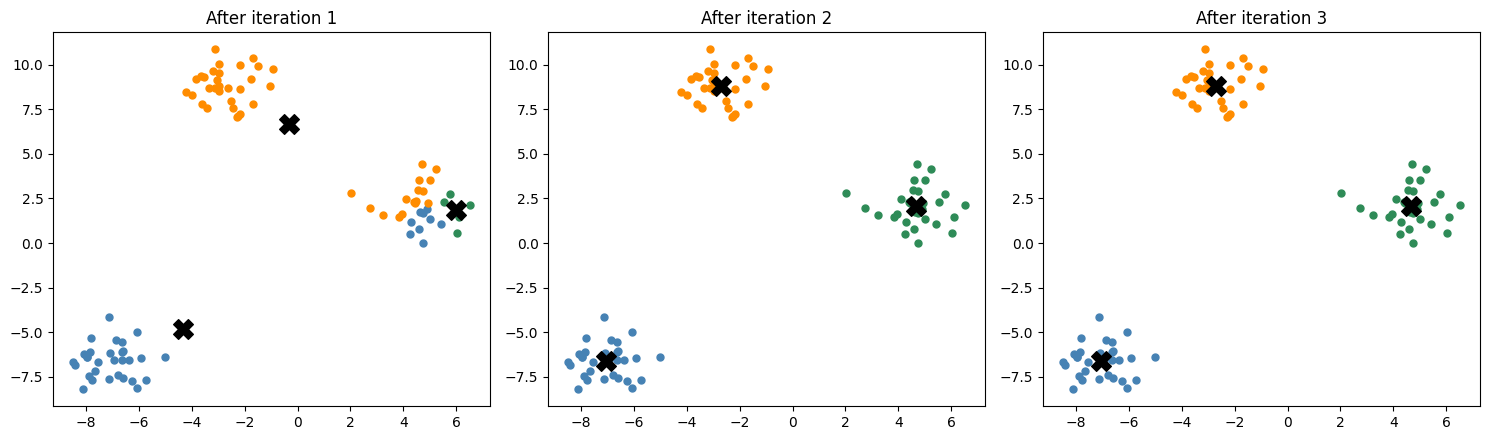

In [15]:
colors = ["steelblue", "darkorange", "seagreen"]
n_iters = len(history)

fig, axes = plt.subplots(1, n_iters, figsize=(5 * n_iters, 4.5))
if n_iters == 1:
    axes = [axes]

for ax, (labels, centers) in zip(axes, history):
    for i in range(k):
        pts = X[labels == i]
        ax.scatter(pts[:, 0], pts[:, 1], s=25, color=colors[i])
    ax.scatter(centers[:, 0], centers[:, 1], s=200, marker="X", c="black")

for i, ax in enumerate(axes):
    ax.set_title(f"After iteration {i + 1}")

plt.tight_layout()
plt.show()

# Impact of initial random means

In [16]:
history = run_kmeans_with_history(X, k=3, seed=1)
print(f"K-Means converged after {len(history)} iterations")

K-Means converged after 4 iterations


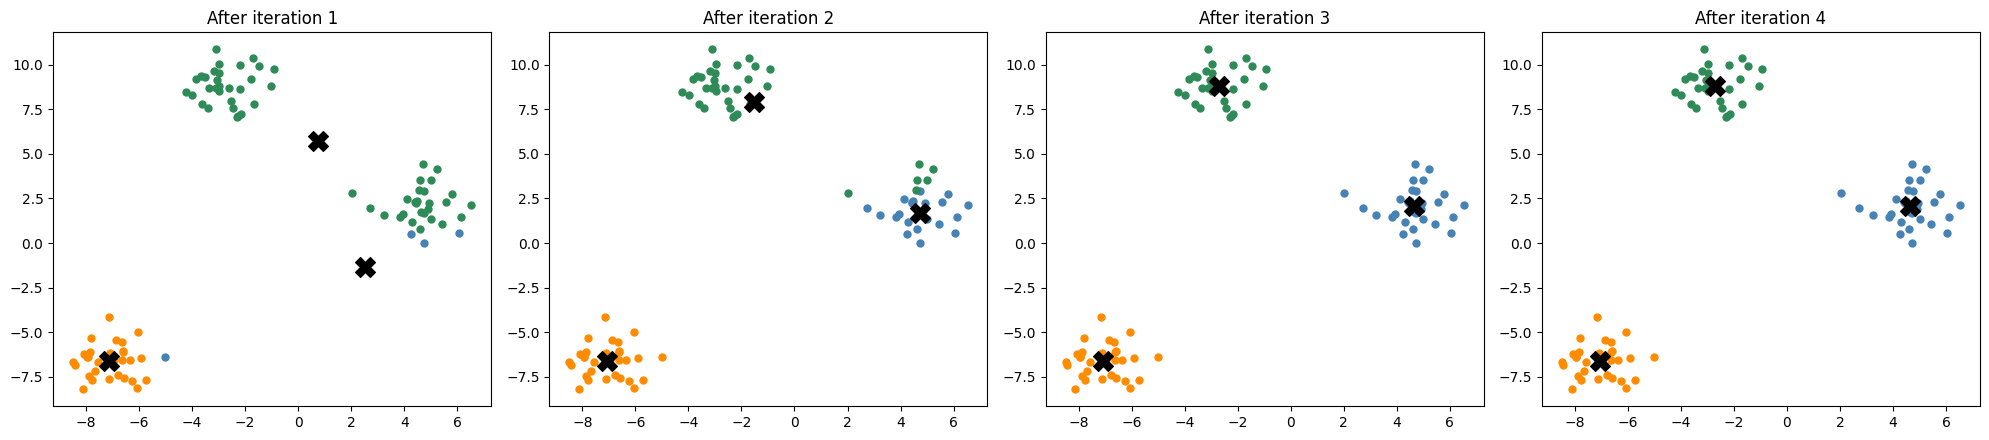

In [17]:
colors = ["steelblue", "darkorange", "seagreen"]
n_iters = len(history)

fig, axes = plt.subplots(1, n_iters, figsize=(5 * n_iters, 4.5))
if n_iters == 1:
    axes = [axes]

for ax, (labels, centers) in zip(axes, history):
    for i in range(k):
        pts = X[labels == i]
        ax.scatter(pts[:, 0], pts[:, 1], s=25, color=colors[i])
    ax.scatter(centers[:, 0], centers[:, 1], s=200, marker="X", c="black")

for i, ax in enumerate(axes):
    ax.set_title(f"After iteration {i + 1}")

plt.tight_layout()
plt.show()

# Comparing to scikit-learn

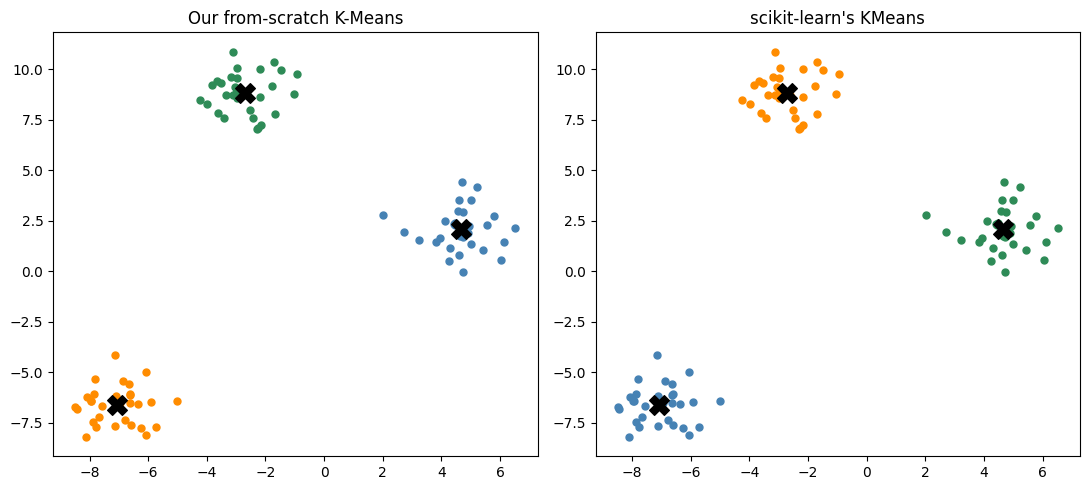

In [18]:
from sklearn.cluster import KMeans

sk_kmeans = KMeans(n_clusters=3, random_state=7, n_init=10)
sk_labels = sk_kmeans.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

final_labels, final_centers = history[-1]
for i in range(k):
    pts = X[final_labels == i]
    axes[0].scatter(pts[:, 0], pts[:, 1], s=25, color=colors[i])
axes[0].scatter(final_centers[:, 0], final_centers[:, 1], s=200, marker="X", c="black")
axes[0].set_title("Our from-scratch K-Means")

for i in range(k):
    pts = X[sk_labels == i]
    axes[1].scatter(pts[:, 0], pts[:, 1], s=25, color=colors[i])
axes[1].scatter(sk_kmeans.cluster_centers_[:, 0], sk_kmeans.cluster_centers_[:, 1],
                s=200, marker="X", c="black")
axes[1].set_title("scikit-learn's KMeans")

plt.tight_layout()
plt.show()

---
# Part 3: DBSCAN on Two Moons

# DBSCAN on Two Moons

### Generate data

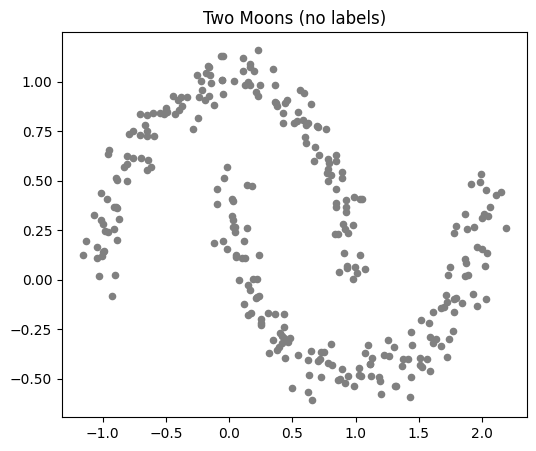

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN, KMeans

X, y_true = make_moons(n_samples=300, noise=0.07, random_state=42)

plt.scatter(X[:, 0], X[:, 1], s=20, color="gray")
plt.title("Two Moons (no labels)")
plt.show()


### Why K-Means fails here

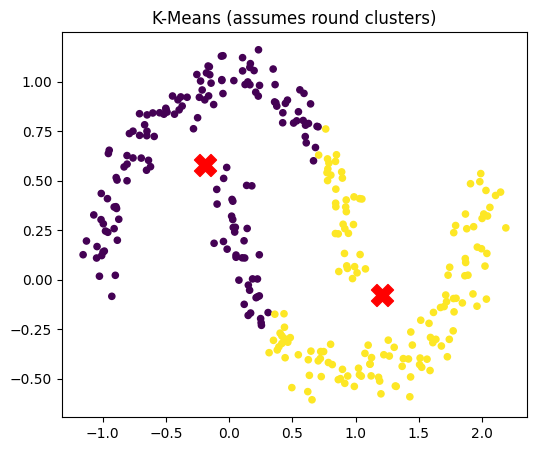

In [20]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

plt.scatter(X[:, 0], X[:, 1], c=km_labels, cmap="viridis", s=20)
plt.scatter(centers[:, 0], centers[:, 1], s=250, marker="X", c="red", label="starting centers")
plt.title("K-Means (assumes round clusters)")
plt.show()


### Apply DBSCAN

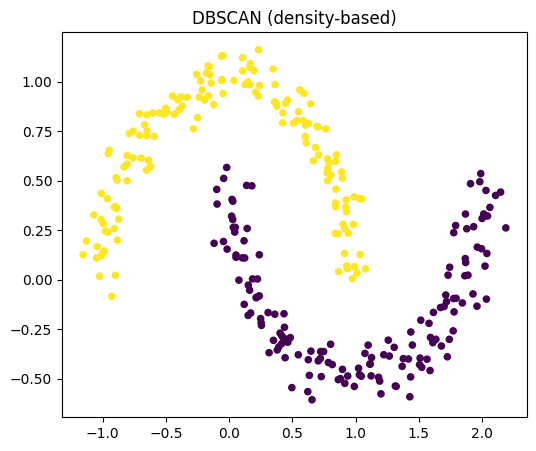

In [21]:
dbscan = DBSCAN(eps=0.2, min_samples=5)
db_labels = dbscan.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=db_labels, cmap="viridis", s=20)
plt.title("DBSCAN (density-based)")
plt.show()


### Noise points (label = -1)

In [22]:
n_noise = np.sum(db_labels == -1)
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print(f"Clusters found: {n_clusters}")
print(f"Noise points: {n_noise}")


Clusters found: 2
Noise points: 0


### DBSCAN hyperparameters
- **eps**: max distance between two points to be considered neighbors
- **min_samples**: min neighbors (incl. itself) needed to form a dense region (core point)

### Effect of `eps` (min_samples fixed = 5)

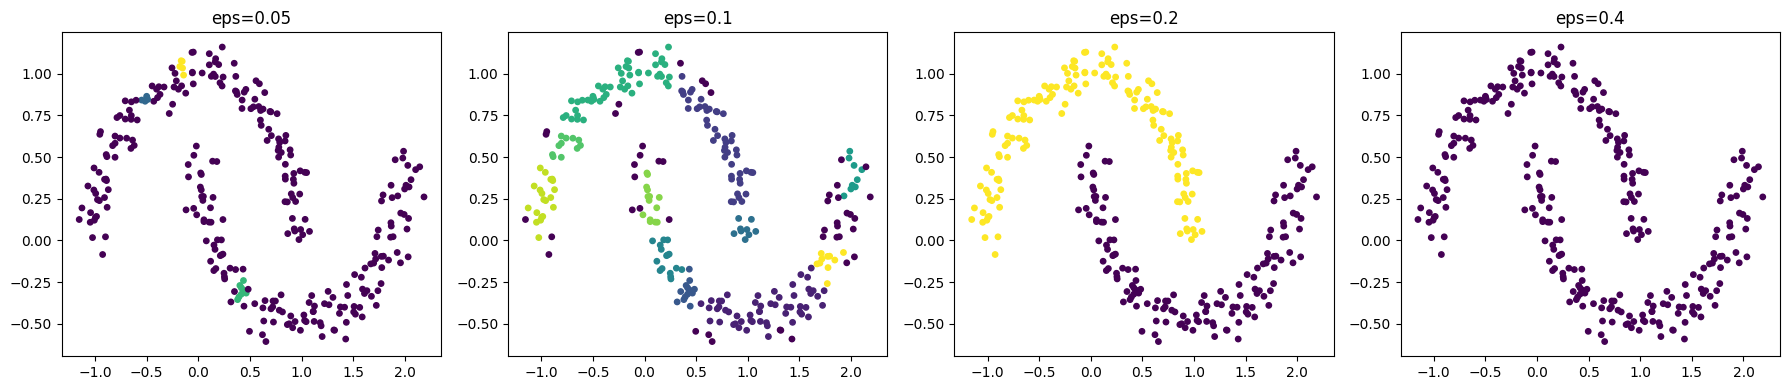

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, eps in zip(axes, [0.05, 0.1, 0.2, 0.4]):
    labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X)
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=15)
    ax.set_title(f"eps={eps}")

plt.tight_layout()
plt.show()


### Effect of `min_samples` (eps fixed = 0.2)

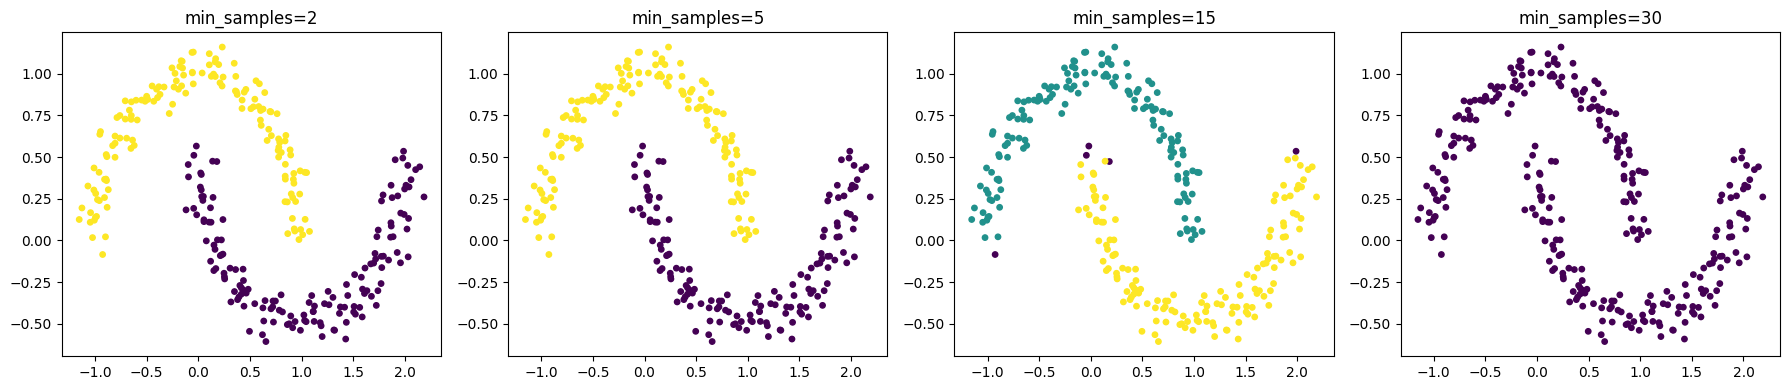

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, ms in zip(axes, [2, 5, 15, 30]):
    labels = DBSCAN(eps=0.2, min_samples=ms).fit_predict(X)
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=15)
    ax.set_title(f"min_samples={ms}")

plt.tight_layout()
plt.show()


### Combined grid: `eps` x `min_samples`

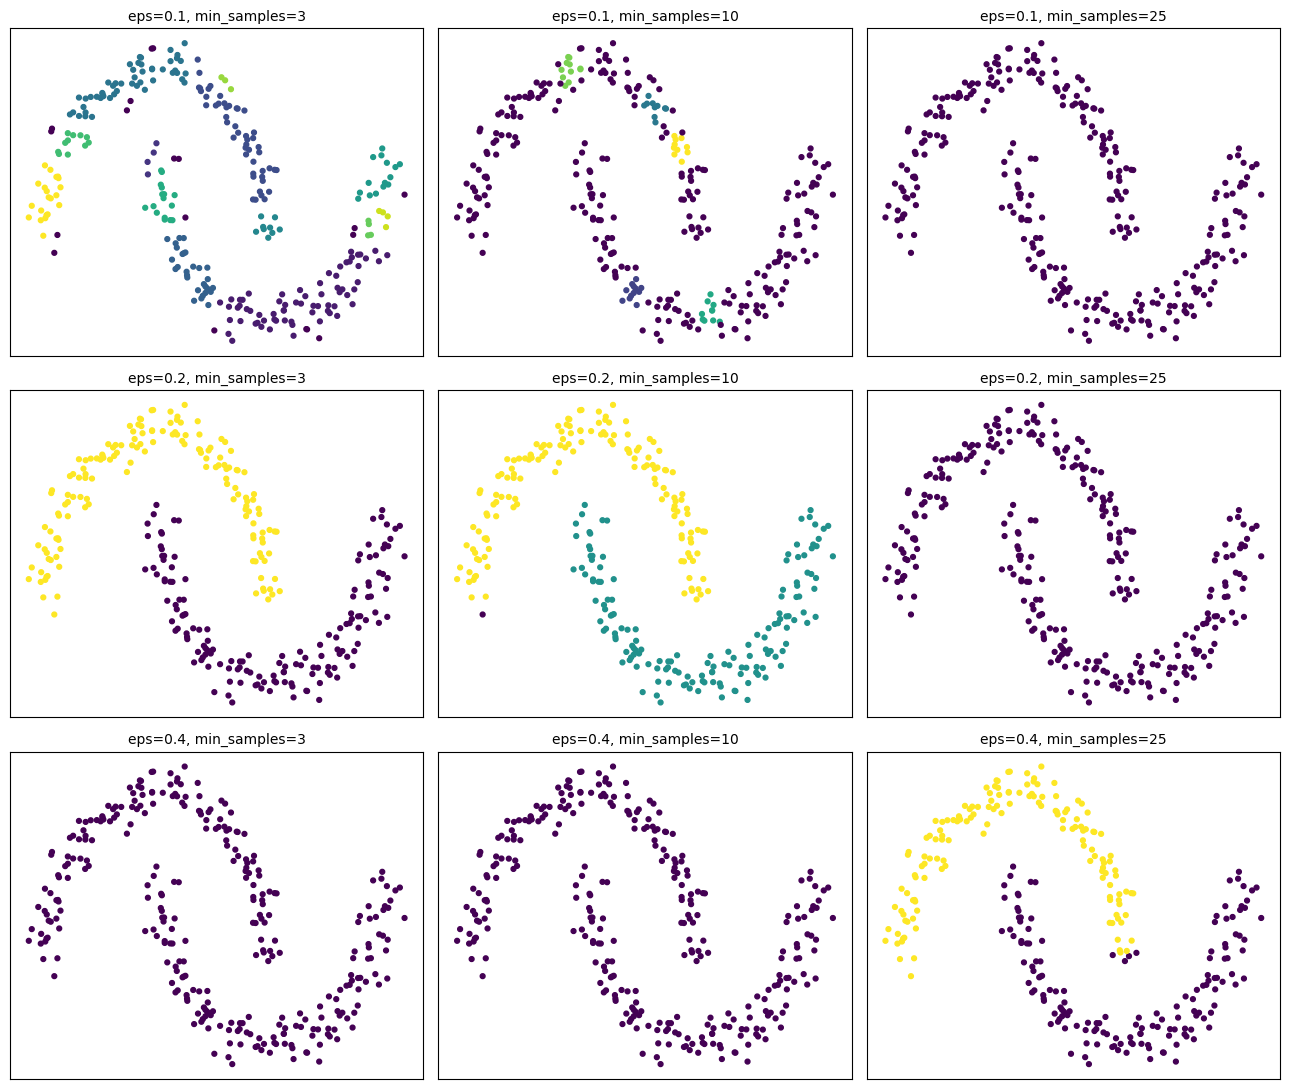

In [25]:
eps_values = [0.1, 0.2, 0.4]
min_samples_values = [3, 10, 25]

fig, axes = plt.subplots(len(eps_values), len(min_samples_values), figsize=(13, 11))

for i, eps in enumerate(eps_values):
    for j, ms in enumerate(min_samples_values):
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
        ax = axes[i, j]
        ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=12)
        ax.set_title(f"eps={eps}, min_samples={ms}", fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()


---
# Part 4: Anomaly Detection with DBSCAN

# Anomaly Detection with DBSCAN

DBSCAN groups points into dense regions and labels anything that
doesn't belong to a dense region as **noise** (`label == -1`).
Those noise points are exactly the anomalies / outliers we want to
find — no separate "outlier detection" algorithm needed.


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 5)


### Simulate sensor data (2 normal operating regions + outliers)

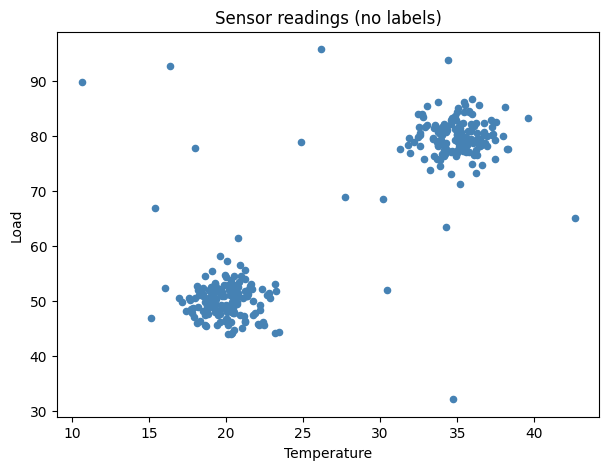

In [27]:
normal1 = np.random.normal(loc=[20, 50], scale=[1.5, 3], size=(150, 2))
normal2 = np.random.normal(loc=[35, 80], scale=[1.5, 3], size=(150, 2))
outliers = np.random.uniform(low=[10, 20], high=[45, 100], size=(15, 2))

X = np.vstack([normal1, normal2, outliers])
df = pd.DataFrame(X, columns=["temperature", "load"])

plt.scatter(df["temperature"], df["load"], s=20, color="steelblue")
plt.xlabel("Temperature")
plt.ylabel("Load")
plt.title("Sensor readings (no labels)")
plt.show()


### Scale features, then run DBSCAN

In [28]:
X_scaled = StandardScaler().fit_transform(df[["temperature", "load"]])

dbscan = DBSCAN(eps=0.3, min_samples=6)
df["cluster"] = dbscan.fit_predict(X_scaled)

df["cluster"].value_counts()


,count
cluster,
1,151
0,150
-1,14


### Visualize: normal clusters vs. anomalies (label -1)

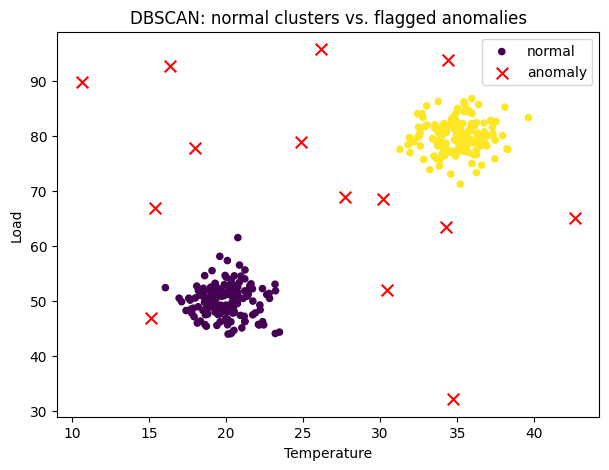

Anomalies flagged: 14 / 315


In [29]:
normal_mask = df["cluster"] != -1
anomaly_mask = df["cluster"] == -1

plt.scatter(df.loc[normal_mask, "temperature"], df.loc[normal_mask, "load"],
            c=df.loc[normal_mask, "cluster"], cmap="viridis", s=20, label="normal")
plt.scatter(df.loc[anomaly_mask, "temperature"], df.loc[anomaly_mask, "load"],
            c="red", s=70, marker="x", label="anomaly")
plt.xlabel("Temperature")
plt.ylabel("Load")
plt.title("DBSCAN: normal clusters vs. flagged anomalies")
plt.legend()
plt.show()

print(f"Anomalies flagged: {anomaly_mask.sum()} / {len(df)}")


### Why K-Means doesn't work well for this

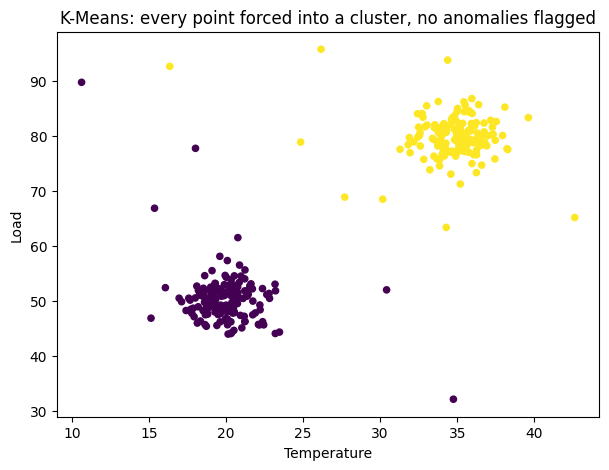

In [30]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)
centers = kmeans.cluster_centers_

plt.scatter(df["temperature"], df["load"], c=km_labels, cmap="viridis", s=20)
#plt.scatter(centers[:, 0], centers[:, 1], s=250, marker="X", c="red", label="starting centers")
plt.xlabel("Temperature")
plt.ylabel("Load")
plt.title("K-Means: every point forced into a cluster, no anomalies flagged")
plt.show()


K-Means has no concept of "noise" — every point, including
the outliers, gets forced into one of the k clusters. It can't
flag anomalies on its own the way DBSCAN can.
